In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.collections import LineCollection
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
plt.style.use('properties.mplstyle')

In [5]:
results_folder = "../results/Navigation/3D"
path_sizes = "../results/size_effects/3D"

create_folder(results_folder)
create_folder(path_sizes)

In [3]:
process_all_roots("../Data/bond_percolation", verbose=True, clean_outputs=False)
summarize_all_dirs("../Data/bond_percolation", verbose=True)
clear_output()

In [2]:
df = pd.read_csv("../Data/bond_percolation/all_data_3D.dat", sep=' ').sort_values('rho')
df

,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,128,3000,0.000001,2,0.008523,1.0,0.5,1,700,0.697425,0.000877,134.040000,0.051641,7.009120e+05,1.716171e+03
1,128,3000,0.000001,2,0.008523,1.0,0.5,2,700,0.692514,0.000886,134.052857,0.051446,7.032390e+05,1.616482e+03
5587,512,3000,0.000001,4,0.009771,1.0,0.1,4,50,0.252371,0.000066,2378.000000,9.380353,7.806891e+06,2.812303e+04
5586,512,3000,0.000001,4,0.009771,1.0,0.1,3,50,0.252118,0.000068,2349.380000,9.556572,7.806131e+06,2.799340e+04
5584,512,3000,0.000001,4,0.009771,1.0,0.1,1,50,0.251597,0.000066,2307.860000,13.597539,7.806608e+06,2.806818e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5189,512,3000,0.000001,1,1.000000,0.4,0.1,1,30,0.249538,0.000069,3588.533333,59.010261,1.091130e+07,1.771831e+05
5190,512,3000,0.000001,1,1.000000,0.8,0.1,1,30,0.249527,0.000071,3524.100000,66.425091,1.108715e+07,2.002477e+05
5191,512,3000,0.000001,1,1.000000,1.0,0.1,1,30,0.249385,0.000070,3487.266667,77.043560,1.114699e+07,2.374546e+05
7856,1024,3000,0.000001,1,1.000000,0.4,0.1,1,10,0.248877,0.000070,12064.900000,374.010174,3.612405e+07,1.122344e+06


In [14]:
L_alvo = [128, 256, 512]
nc = 2

df_f = df[(df["L"].isin(L_alvo)) & (df["nc"] == nc)].copy()

# ajuste o número de casas conforme seu dataset (10–12 costuma bastar)
df_f["rho_key"] = df_f["rho"].round(12)

rhos_comuns = (
    df_f.groupby("rho_key")["L"]
        .nunique()
        .loc[lambda s: s == len(L_alvo)]
        .index
)

df_comum = df_f[df_f["rho_key"].isin(rhos_comuns)].copy()

# se você quer ver os valores "originais" de rho correspondentes:
df_comum["rho"].unique()

with np.printoptions(threshold=np.inf):
    print(df_comum["rho_key"].unique().tolist())

[0.02106, 0.023568, 0.026075, 0.028583, 0.03109, 0.033598, 0.036106, 0.038613, 0.041121, 0.043628, 0.046136, 0.048643, 0.051151, 0.053658, 0.056166, 0.058673, 0.061181, 0.063688, 0.066196, 0.068704, 0.071211, 0.073719, 0.076226, 0.078734, 0.081241, 0.083749, 0.086256, 0.088764, 0.091271, 0.093779, 0.096286, 0.098794, 0.1013, 0.10381, 0.10632, 0.10882, 0.11133, 0.11384, 0.11635, 0.11885, 0.12136, 0.12387, 0.125, 0.12638, 0.12888, 0.13139, 0.1339, 0.13641, 0.13891, 0.14142, 0.14393, 0.14644, 0.14894, 0.15145, 0.15396, 0.15647, 0.15897, 0.16148, 0.16399, 0.1665, 0.16901, 0.17151, 0.17402, 0.17653, 0.17904, 0.18154, 0.18405, 0.18656, 0.18907, 0.19157, 0.19408, 0.19659, 0.1991, 0.2016, 0.20411, 0.20662, 0.20913, 0.21163, 0.21414, 0.21665, 0.21916, 0.22166, 0.22417, 0.22668, 0.22919, 0.23169, 0.2342, 0.23671, 0.23922, 0.24172, 0.24423, 0.24674, 0.24925, 0.25175, 0.25426, 0.25677, 0.25928, 0.26178, 0.26429, 0.2668, 0.26931, 0.27181, 0.27432, 0.27683, 0.27934, 0.28184, 0.28435, 0.28686, 0.2893

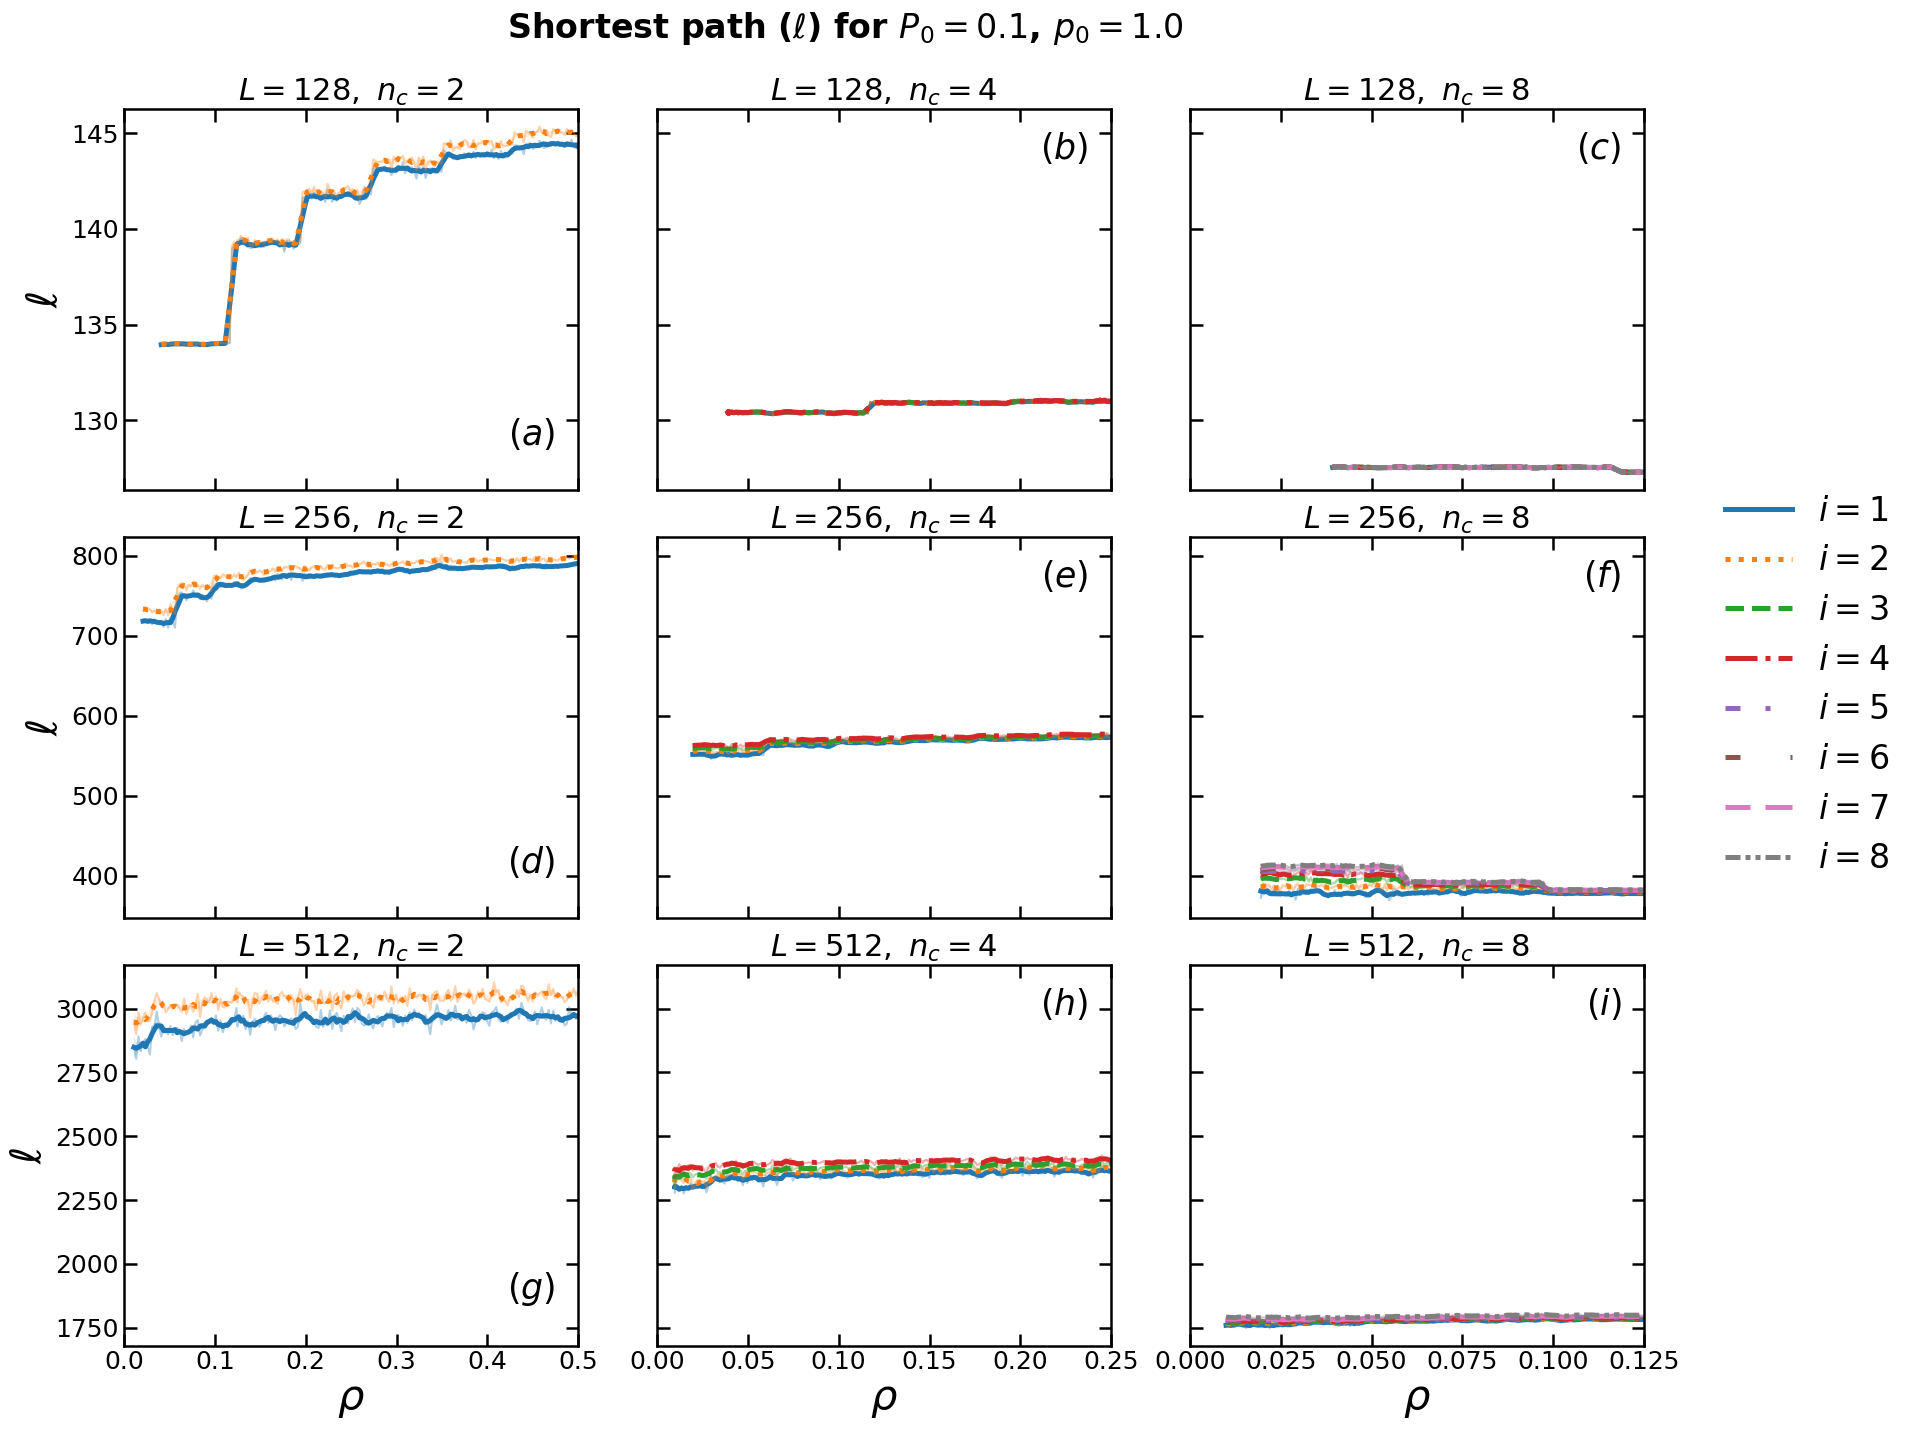

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L_list   = [128, 256, 512]     # linhas
NC_LIST  = [2, 4, 8]           # colunas
WINDOW   = 5
P0       = 0.1
p0       = 1.0

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

labels_fig = ["$(a)$", "$(b)$", "$(c)$", 
              "$(d)$", "$(e)$", "$(f)$",
              "$(g)$", "$(h)$", "$(i)$"]

fig, axes = plt.subplots(3, 3, figsize=(17, 15), sharex='col', sharey='row')
thickness_axes = 1.8
font_tick_size = 18
legend_lines = {}

for i, L in enumerate(L_list):          # linhas -> L
    for j, nc in enumerate(NC_LIST):    # colunas -> n_c
        ax = axes[i, j]
        orders = list(range(1, nc + 1))
        count = 0

        for order in orders:
            df_f = df[
                (df["L"] == L) &
                (df["nc"] == nc) &
                (df["order"] == order) &
                (df["P0"] == P0) &
                (df["p0"] == p0)
            ].copy()

            if df_f.empty:
                continue

            df_f = df_f.sort_values("rho")

            x = df_f["rho"].to_numpy()
            y = df_f["shortest_path"].to_numpy()

            y_ma = (
                pd.Series(y)
                .rolling(window=WINDOW,
                         center=True,
                         min_periods=max(3, WINDOW // 2))
                .mean()
                .to_numpy()
            )
            y_std = (
                pd.Series(y)
                .rolling(window=WINDOW,
                         center=True,
                         min_periods=max(3, WINDOW // 2))
                .std()
                .to_numpy()
            )
            y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y) + 1)))

            ax.plot(x, y, alpha=0.35)
            lines, = ax.plot(x, y_ma, linewidth=2*thickness_axes, color=colors[count],
                            ls=ls[count],
                            label=fr"$i = {order}$")
            ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)
            count += 1
            if order not in legend_lines:
                legend_lines[order] = lines
        
        ax.set_xlim([0, 1 / nc])
        # ax.tick_params(axis='both', which='major', direction='in',
        #                length=10, width=thickness_axes, labelsize=18, top=True, bottom=True, right=True)
        for spine in ax.spines.values():
            spine.set_linewidth(thickness_axes)
        if(j==0):
            posx,posy = 0.95, 0.10
        else:
            posx,posy = 0.95, 0.85
        
        ax.text(posx, posy, labels_fig[i * len(NC_LIST) + j],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)

#        ax.legend(fontsize=15)
        ax.set_title(rf"$L = {L},\ n_c = {nc}$", fontsize=22)
        ax.tick_params(axis='both', which='major', labelsize=font_tick_size,
                    length=9, width=thickness_axes,
                    direction='in', top=True, bottom=True, left=True, right=True)
        ax.tick_params(axis='both', which='minor', labelsize=font_tick_size,
                    length=6, width=thickness_axes,
                    direction='in', top=True, bottom=True, left=True, right=True)

        # n = 5
        # ax.xaxis.set_minor_locator(AutoMinorLocator(n))
        # ax.yaxis.set_minor_locator(AutoMinorLocator(n))
        # rótulos só onde precisa
for i in range(3):
    axes[i, 0].set_ylabel(r"$\ell$", fontsize=30)
for j in range(3):
    axes[2, j].set_xlabel(r"$\rho$", fontsize=30)

# ordena por i e cria listas
handles = [legend_lines[i] for i in sorted(legend_lines.keys())]
labels = [fr'$i={i}$' for i in sorted(legend_lines.keys())]

# adiciona o handle do p_c
pc_handle = Line2D([0], [0], linestyle='--', linewidth=1.6, color='k')
handles.append(pc_handle)


fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           frameon=False, fontsize=24)

fig.suptitle(fr"Shortest path ($\ell$) for $P_0 = {P0}$, $p_0 = {p0}$",
             fontsize=24, fontweight='bold',y=0.95)
fig.tight_layout(rect=[0, 0, 1, 0.95])  # deixa espaço para o suptitle
fig.savefig(
    results_folder + "/shortest_rho_L_nc.pdf",
    bbox_inches='tight',   # <- inclui a legenda na caixa
    pad_inches=0.05        # opcional, um espacinho extra
)
plt.show()


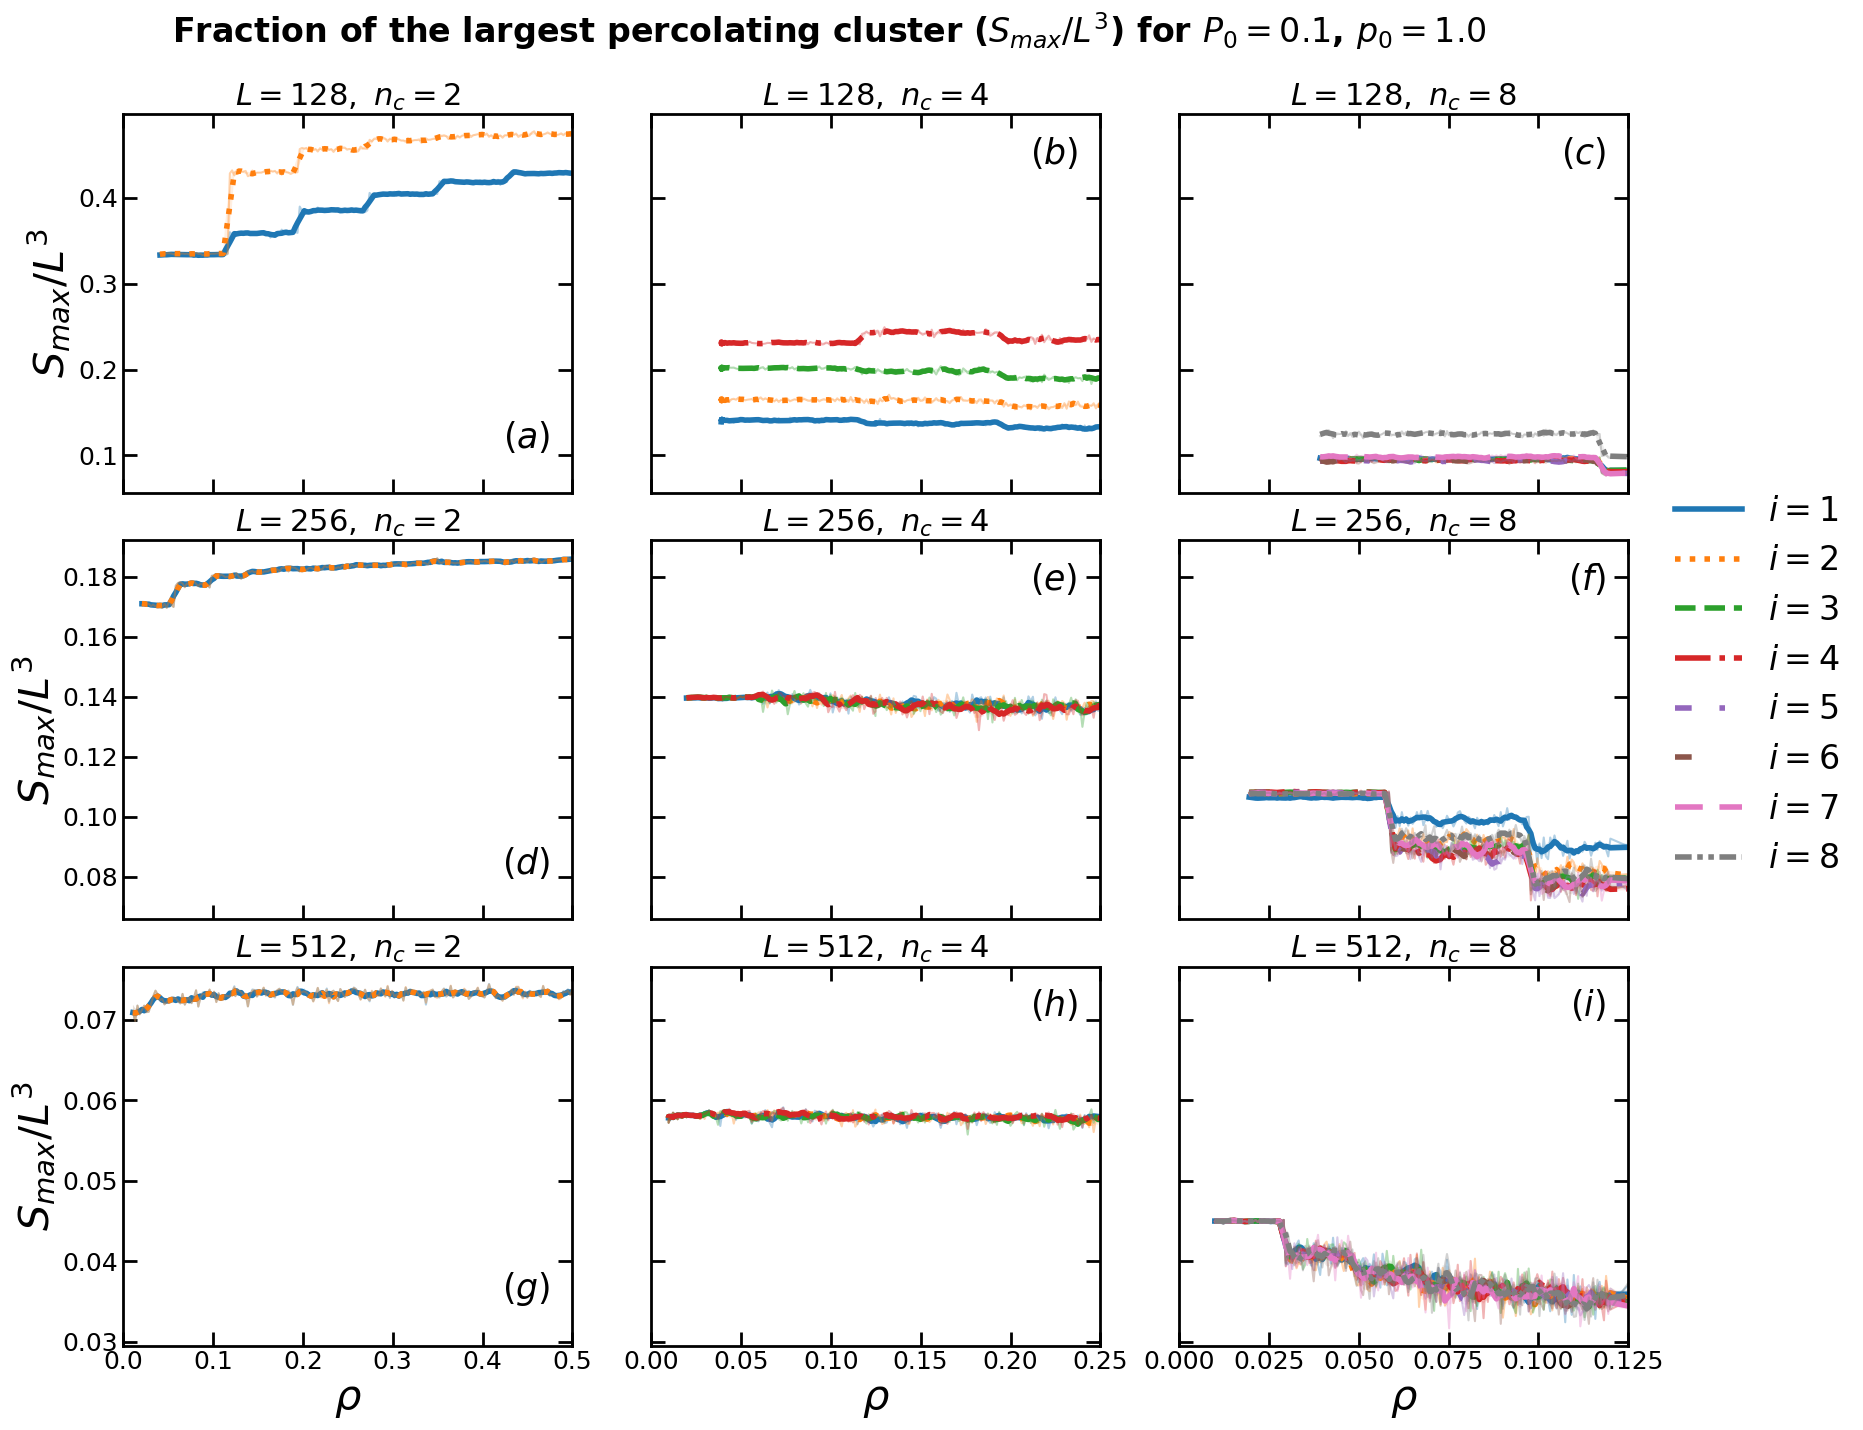

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L_list   = [128, 256, 512]     # linhas
NC_LIST  = [2, 4, 8]           # colunas
WINDOW   = 5
P0       = 0.1
p0       = 1.0

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

labels_fig = ["$(a)$", "$(b)$", "$(c)$", 
              "$(d)$", "$(e)$", "$(f)$",
              "$(g)$", "$(h)$", "$(i)$"]

fig, axes = plt.subplots(3, 3, figsize=(17, 15), sharex='col', sharey='row')
thickness_axes = 2.0

legend_lines = {}

for i, L in enumerate(L_list):          # linhas -> L
    for j, nc in enumerate(NC_LIST):    # colunas -> n_c
        ax = axes[i, j]
        orders = list(range(1, nc + 1))
        count = 0

        for order in orders:
            df_f = df[
                (df["L"] == L) &
                (df["nc"] == nc) &
                (df["order"] == order) &
                (df["P0"] == P0) &
                (df["p0"] == p0)
            ].copy()

            if df_f.empty:
                continue

            df_f = df_f.sort_values("rho")
            VOL = L**3
            x = df_f["rho"].to_numpy()
            y = df_f["S_perc"].to_numpy()/VOL

            y_ma = (
                pd.Series(y)
                .rolling(window=WINDOW,
                         center=True,
                         min_periods=max(3, WINDOW // 2))
                .mean()
                .to_numpy()
            )
            y_std = (
                pd.Series(y)
                .rolling(window=WINDOW,
                         center=True,
                         min_periods=max(3, WINDOW // 2))
                .std()
                .to_numpy()
            )
            y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y) + 1)))

            ax.plot(x, y, alpha=0.35)
            lines, = ax.plot(x, y_ma, linewidth=2*thickness_axes, color=colors[count],
                            ls=ls[count],
                            label=fr"$i = {order}$")
            ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)
            count += 1
            if order not in legend_lines:
                legend_lines[order] = lines
        
        ax.set_xlim([0, 1 / nc])
        ax.tick_params(axis='both', which='major', direction='in',
                       length=10, width=thickness_axes, labelsize=18, top=True, bottom=True, right=True)
        for spine in ax.spines.values():
            spine.set_linewidth(thickness_axes)
        if(j==0):
            posx,posy = 0.95, 0.10
        else:
            posx,posy = 0.95, 0.85
        
        ax.text(posx, posy, labels_fig[i * len(NC_LIST) + j],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)
#        ax.legend(fontsize=15)
        ax.set_title(rf"$L = {L},\ n_c = {nc}$", fontsize=22)

# rótulos só onde precisa
for i in range(3):
    axes[i, 0].set_ylabel(r"$S_{max}/L^3$", fontsize=30)
for j in range(3):
    axes[2, j].set_xlabel(r"$\rho$", fontsize=30)

# ordena por i e cria listas
handles = [legend_lines[i] for i in sorted(legend_lines.keys())]
labels = [fr'$i={i}$' for i in sorted(legend_lines.keys())]

# adiciona o handle do p_c
pc_handle = Line2D([0], [0], linestyle='--', linewidth=1.6, color='k')
handles.append(pc_handle)

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.98, 0.5),
           frameon=False, fontsize=24)

fig.suptitle(fr"Fraction of the largest percolating cluster ($S_{{max}}/L^3$) for $P_0 = {P0}$, $p_0 = {p0}$",
             fontsize=24, fontweight='bold',y=0.95)
fig.tight_layout(rect=[0, 0, 1, 0.95])  # deixa espaço para o suptitle
fig.savefig(
    results_folder + "/Smax_rho_L_nc.pdf",
    bbox_inches='tight',   # <- inclui a legenda na caixa
    pad_inches=0.05        # opcional, um espacinho extra
)
plt.show()


In [ ]:
L_lst = [128, 256, 512]
nc = 8
rho = 0.12
orders = [i for i in range(1,nc+1)]
for L in L_lst:
    df_filter = df[(df["nc"]==nc) & (df["rho"]==rho) & (df["L"]==L)]
    
    print(df_filter)

        L    Nt         k  nc   rho   p0   P0  order  N_samples    p_mean  \
2912  128  3000  0.000001   8  0.12  1.0  0.1      1        500  0.999739   
2913  128  3000  0.000001   8  0.12  1.0  0.1      2        500  0.999052   
2915  128  3000  0.000001   8  0.12  1.0  0.1      4        500  0.998979   
2914  128  3000  0.000001   8  0.12  1.0  0.1      3        500  0.995658   
2919  128  3000  0.000001   8  0.12  1.0  0.1      8        500  0.996800   
2918  128  3000  0.000001   8  0.12  1.0  0.1      7        500  0.996460   
2917  128  3000  0.000001   8  0.12  1.0  0.1      6        500  0.999755   
2916  128  3000  0.000001   8  0.12  1.0  0.1      5        500  0.996120   

         p_err  shortest_path  shortest_path_err      S_perc   S_perc_err  
2912  0.000008        127.258           0.024982  172762.266  3098.967678  
2913  0.000022        127.258           0.024982  172132.302  2934.505002  
2915  0.000028        127.256           0.024620  167274.284  2942.689440  
29

In [68]:

plt.style.use('properties.mplstyle')

i = 1, a = 2.08 ± 0.07
i = 2, a = 2.08 ± 0.07
i = 3, a = 2.10 ± 0.06
i = 4, a = 2.10 ± 0.06


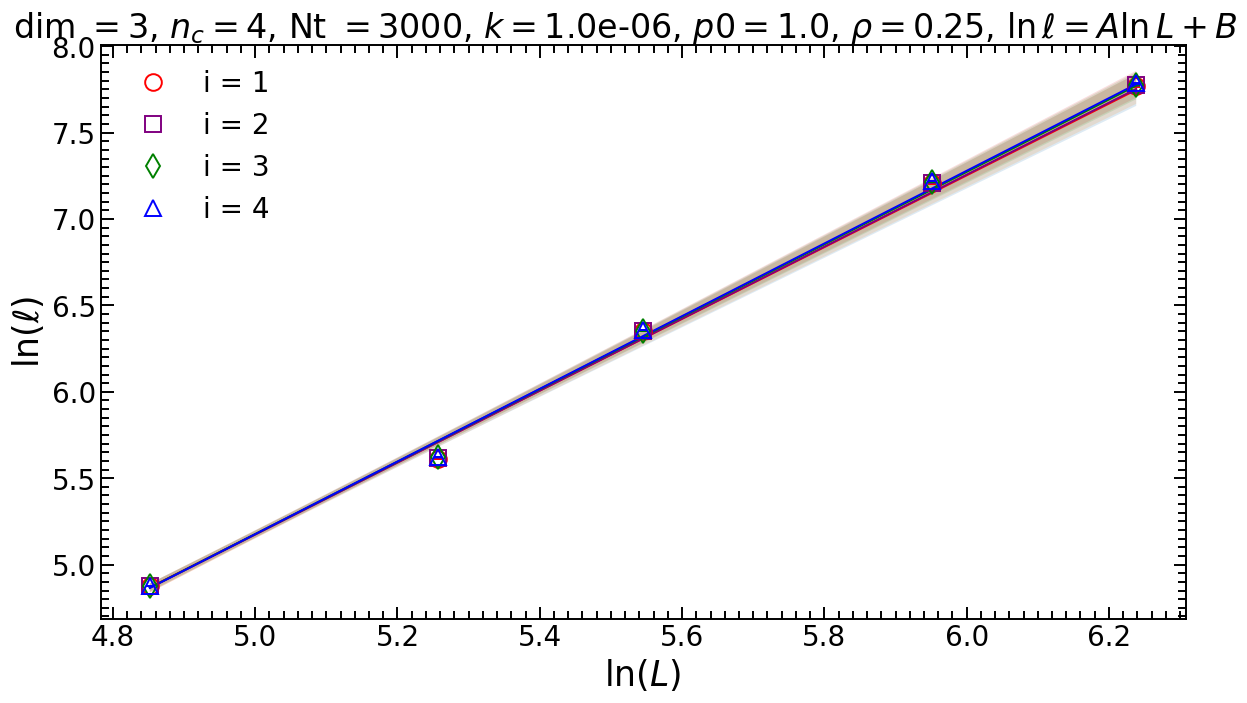

In [ ]:
L_lst = [128, 192, 256, 384, 512]
nc = 4
Nt = 3000
k = 1.0e-06
p0 = 1.0
P0 = 0.1
dim = 3
# smallest value of rho with percolation for L=128
rho_min = df[(df['L']==128) & (df["nc"]==nc) & (df["P0"]==0.1)]['rho'].min()
# biggest value of rho with percolation for L=128 (1/nc)
rho_max = df[(df['L']==128) & (df["nc"]==nc) & (df["P0"]==0.1)]['rho'].max()

df_all = df[(df['Nt']==Nt) & (df['k']==k) & (df['nc']==nc) & (df['p0']==p0) & (df['P0']==P0) & (df['rho']==rho_max)]

fig, ax = plt.subplots(figsize=(14, 7))
orders = [i for i in range(1,nc+1)]


ms = 12
font_tick_size = 20
font_label_size = 25
font_legend_size = 20
markers = ["o", "s", "d", "^"]
mew = 1.4
thickness = 1.4
colors  = ["red", "purple", "green", "blue"]

for idx, ord in enumerate(orders):
    df_sub = df_all[(df_all['L'].isin(L_lst)) & (df_all['order']==ord)].sort_values('L')
    prop = df_sub["shortest_path"]
    prop_err = df_sub["shortest_path_err"]
    
    x_scale = np.log(L_lst)
    y_scale = np.log(prop)
    y_err = prop_err / prop
        
    ax.errorbar(x_scale, y_scale, yerr=y_err,
                fmt=markers[idx], linestyle='None',  # <- sem traço
                markersize=ms, markerfacecolor='none',
                markeredgewidth=mew, markeredgecolor=colors[idx],
                ecolor=colors[idx], capsize=3)

    # (2) regressão linear ponderada: y = a*x + b
    p, cov = np.polyfit(x_scale, y_scale, 1, w=1.0/y_err, cov=True)  # w = 1/sigma
    a, b = p
    a_err, b_err = np.sqrt(np.diag(cov))

    # (3) reta da regressão
    x_fit = np.linspace(x_scale.min(), x_scale.max(), 200)
    y_fit = a*x_fit + b
    ax.plot(x_fit, y_fit, color=colors[idx], linewidth=thickness)
    y_fit_err = np.sqrt(cov[0,0]*x_fit**2 + 2*cov[0,1]*x_fit + cov[1,1])
    ax.fill_between(x_fit, y_fit - y_fit_err, y_fit + y_fit_err, alpha=0.15)

    print(rf"i = {ord}, a = {a:.2f} ± {a_err:.2f}")


for spine in ax.spines.values():
    spine.set_linewidth(thickness)

ax.set_xlabel(r"$\ln(L)$", fontsize=font_label_size)
ax.set_ylabel(r"$\ln(\ell)$", fontsize=font_label_size)
ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness, 
               direction='in', top=True, bottom=True, left=True, right=True)

ax.tick_params(axis='both', which='minor', labelsize=font_tick_size, length=6, width=thickness, 
               direction='in', top=True, bottom=True, left=True, right=True)
# Ticks minor
n=10
ax.xaxis.set_minor_locator(AutoMinorLocator(n))
ax.yaxis.set_minor_locator(AutoMinorLocator(n))

# --- legenda só com símbolos ---
legend_handles = [
    Line2D([0], [0],
           marker=markers[idx],
           linestyle='None',            # <- remove o traço na legenda
           color=colors[idx],
           markerfacecolor='none',
           markeredgewidth=mew,
           markersize=ms,
           label=f'i = {ord}')
    for idx, ord in enumerate(orders)
]

ax.legend(handles=legend_handles, fontsize=font_legend_size,frameon=False)

supt = fig.suptitle(rf"dim $= {dim}$, $n_c = {nc}$, Nt $= {Nt}$, $k = ${k:.1e}, $p0 = {p0}$, $\rho = {0.25}$, $\ln \ell = A\ln L + B$", fontsize=24, y=0.98)

fig.subplots_adjust(top=0.93)

fig.savefig(
    path_sizes + "/shortest_versus_L.png",
    dpi=300,
    bbox_inches="tight",
    bbox_extra_artists=[supt],  # <- inclui o título aqui
    pad_inches=0.05
)


plt.show()

i = 1, a = 2.08 ± 0.07, b = -5.21 ± 0.36
i = 2, a = 2.08 ± 0.07, b = -5.24 ± 0.35
i = 3, a = 2.10 ± 0.06, b = -5.30 ± 0.32
i = 4, a = 2.10 ± 0.06, b = -5.34 ± 0.33


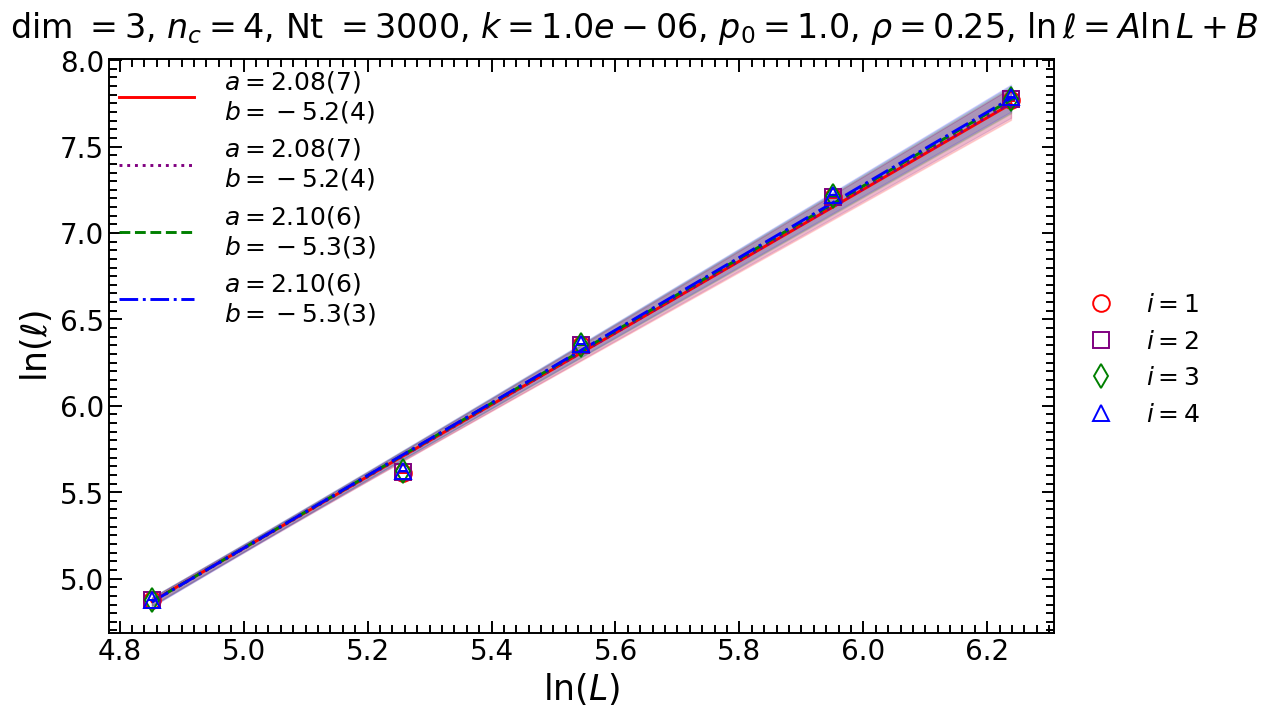

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
from decimal import Decimal, ROUND_HALF_UP, getcontext
from matplotlib.legend_handler import HandlerLine2D

import math

from matplotlib.legend_handler import HandlerLine2D

class HandlerLine2DCentered(HandlerLine2D):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        artists = super().create_artists(
            legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans
        )
        ymid = ydescent + 0.5 * height
        for a in artists:
            if isinstance(a, Line2D):
                xd = np.asarray(a.get_xdata(), dtype=float)
                a.set_ydata(np.full_like(xd, ymid, dtype=float))
        return artists

getcontext().prec = 50

def format_paren(val, err):
    """
    Retorna string no formato valor(erro), com erro arredondado e valor
    com o mesmo número de casas decimais.

    Regra: usa 2 algarismos significativos no erro se o primeiro dígito for 1,
    caso contrário usa 1 algarismo significativo (estilo PDG).
    Ex.: 624.327 ± 2.5 -> 624(3)
          19.0031 ± 0.012 -> 19.003(12)
          21.23 ± 0.0097 -> 21.23(1)
    """
    if err is None or err == 0 or (not np.isfinite(val)) or (not np.isfinite(err)):
        return f"{val:g}"

    err_abs = float(abs(err))
    if err_abs <= 0:
        return f"{val:g}"

    exp = int(math.floor(math.log10(err_abs)))
    m = err_abs / (10**exp)
    first = int(m)

    n_sig = 2 if first == 1 else 1  # PDG-like
    step_exp = exp - (n_sig - 1)

    err_q = Decimal(str(err_abs)).quantize(Decimal(f"1e{step_exp}"), rounding=ROUND_HALF_UP)

    # Remove zeros finais (ex.: 0.010 -> 0.01), para evitar 21.230(10) e virar 21.23(1)
    t = err_q.as_tuple()
    digits = list(t.digits)
    exp2 = t.exponent
    while digits and digits[-1] == 0:
        digits.pop()
        exp2 += 1
    if not digits:
        return f"{val:g}"

    err_int = int("".join(map(str, digits)))
    step_dec = Decimal(f"1e{exp2}")

    val_q = Decimal(str(val)).quantize(step_dec, rounding=ROUND_HALF_UP)

    decimals = max(0, -exp2)
    val_str = f"{val_q:.{decimals}f}" if decimals > 0 else f"{val_q:.0f}"

    return f"{val_str}({err_int})"

# --- parâmetros globais ---
L_lst = [128, 192, 256, 384, 512]
nc = 4
Nt = 3000
k = 1.0e-06
p0 = 1.0
P0 = 0.1
dim = 3

rho_min = df[(df['L'] == 128) & (df["nc"] == nc) & (df["P0"] == 0.1)]['rho'].min()
rho_max = df[(df['L'] == 128) & (df["nc"] == nc) & (df["P0"] == 0.1)]['rho'].max()

df_all = df[(df['Nt'] == Nt) & (df['k'] == k) & (df['nc'] == nc) &
            (df['p0'] == p0) & (df['P0'] == P0) & (df['rho'] == rho_max)]

fig, ax = plt.subplots(figsize=(14, 7))
orders = [i for i in range(1, nc+1)]

ms = 12
font_tick_size = 20
font_label_size = 25
font_legend_size = 18

markers = ["o", "s", "d", "^"]
colors  = ["red", "purple", "green", "blue"]

mew = 1.4
thickness = 1.4

# estilos de linha (mesmos do outro plot)
ls = ['solid', 'dotted', 'dashed', 'dashdot',
      (0, (3, 5, 1, 5)), (0, (3, 10, 1, 10)),
      (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

# listas para as duas legendas
legend_handles_markers = []  # externa (marcadores i=...)
fit_handles_lines = []       # interna (linhas do ajuste)
fit_labels_lines = []        # interna (texto a,b)

for idx, ord in enumerate(orders):
    df_sub = df_all[(df_all['L'].isin(L_lst)) & (df_all['order'] == ord)].sort_values('L')

    prop     = df_sub["shortest_path"].to_numpy()
    prop_err = df_sub["shortest_path_err"].to_numpy()

    # usa os L que realmente existem no df_sub (robusto caso falte algum L)
    L_vals = df_sub["L"].to_numpy(dtype=float)

    x_scale = np.log(L_vals)
    y_scale = np.log(prop)
    y_err   = prop_err / prop  # erro em ln(ℓ): σ_ln ≈ σ/ℓ

    # garante que nenhum sigma seja <= 0
    sigma = y_err.copy().astype(float)
    if np.any(sigma <= 0):
        if np.any(sigma > 0):
            sigma[sigma <= 0] = np.min(sigma[sigma > 0])
        else:
            sigma[:] = 1.0

    # (1) dados com barra de erro
    ax.errorbar(
        x_scale, y_scale, yerr=sigma,
        fmt=markers[idx], linestyle='None',
        markersize=ms, markerfacecolor='none',
        markeredgewidth=mew, markeredgecolor=colors[idx],
        ecolor=colors[idx], capsize=3
    )

    # (2) regressão linear ponderada: y = a*x + b
    p, cov = np.polyfit(x_scale, y_scale, 1, w=1.0/sigma, cov=True)
    a, b = p
    a_err, b_err = np.sqrt(np.diag(cov))

    # (3) reta ajustada
    x_fit = np.linspace(x_scale.min(), x_scale.max(), 200)
    y_fit = a*x_fit + b
    ax.plot(x_fit, y_fit, color=colors[idx],
            linewidth=1.5*thickness, linestyle=ls[idx])

    # (4) banda de incerteza da reta (1σ)
    y_fit_err = np.sqrt(cov[0,0]*x_fit**2 + 2*cov[0,1]*x_fit + cov[1,1])
    ax.fill_between(x_fit, y_fit - y_fit_err, y_fit + y_fit_err,
                    alpha=0.15, color=colors[idx])

    # print no console (se quiser manter)
    print(rf"i = {ord}, a = {a:.2f} ± {a_err:.2f}, b = {b:.2f} ± {b_err:.2f}")

    # -------- legenda externa (marcadores + i) --------
    legend_handles_markers.append(
        Line2D([0], [0],
               marker=markers[idx],
               linestyle='None',
               color=colors[idx],
               markerfacecolor='none',
               markeredgewidth=mew,
               markersize=ms,
               label=rf"$i={ord}$")
    )

    # -------- legenda interna (linhas + parâmetros) --------
    fit_handles_lines.append(
        Line2D([0], [0],
               linestyle=ls[idx],
               color=colors[idx],
               linewidth=1.5*thickness)
    )

    a_fmt = format_paren(a, a_err)
    b_fmt = format_paren(b, b_err)

    fit_labels_lines.append(
        rf"$a={a_fmt}$" "\n"
        rf"$b={b_fmt}$"
    )

# box/spines
for spine in ax.spines.values():
    spine.set_linewidth(thickness)

ax.set_xlabel(r"$\ln(L)$", fontsize=font_label_size)
ax.set_ylabel(r"$\ln(\ell)$", fontsize=font_label_size)

ax.tick_params(axis='both', which='major', labelsize=font_tick_size,
               length=9, width=thickness,
               direction='in', top=True, bottom=True, left=True, right=True)
ax.tick_params(axis='both', which='minor', labelsize=font_tick_size,
               length=6, width=thickness,
               direction='in', top=True, bottom=True, left=True, right=True)

n = 10
ax.xaxis.set_minor_locator(AutoMinorLocator(n))
ax.yaxis.set_minor_locator(AutoMinorLocator(n))

# reservar faixa à direita para legenda externa
fig.subplots_adjust(right=0.80)

# -------- legenda interna: parâmetros das retas --------
leg_inside = ax.legend(
    handles=fit_handles_lines,
    labels=fit_labels_lines,
    loc="upper left",      # <-- só isso
    frameon=False,
    borderaxespad=0.0,
    handlelength=3.0,
    handletextpad=1.2,
    labelspacing=0.45,
    fontsize=font_legend_size,
    handler_map={Line2D: HandlerLine2DCentered()}
)


# -------- legenda externa: marcadores i=... --------
fig_leg = fig.legend(
    handles=legend_handles_markers,
    loc="center left",
    bbox_to_anchor=(0.80, 0.5),
    frameon=False,
    fontsize=font_legend_size
)

supt = fig.suptitle(
    rf"dim $= {dim}$, $n_c = {nc}$, Nt $= {Nt}$, $k = {k:.1e}$, $p_0 = {p0}$, "
    rf"$\rho = {rho_max}$, $\ln \ell = A \ln L + B$",
    fontsize=24, y=1.0
)

fig.subplots_adjust(top=0.93)

fig.savefig(
    path_sizes + "/shortest_versus_L.png",
    dpi=300,
    bbox_inches="tight",
    bbox_extra_artists=(leg_inside, fig_leg, supt),
    pad_inches=0.05
)

plt.show()


R2 = 0.999674, c = 0.25848 ± 4.2e-05
R2 = 0.999698, c = 0.25829 ± 4.1e-05
R2 = 0.999673, c = 0.2574 ± 3.9e-05
R2 = 0.999742, c = 0.25721 ± 4.2e-05


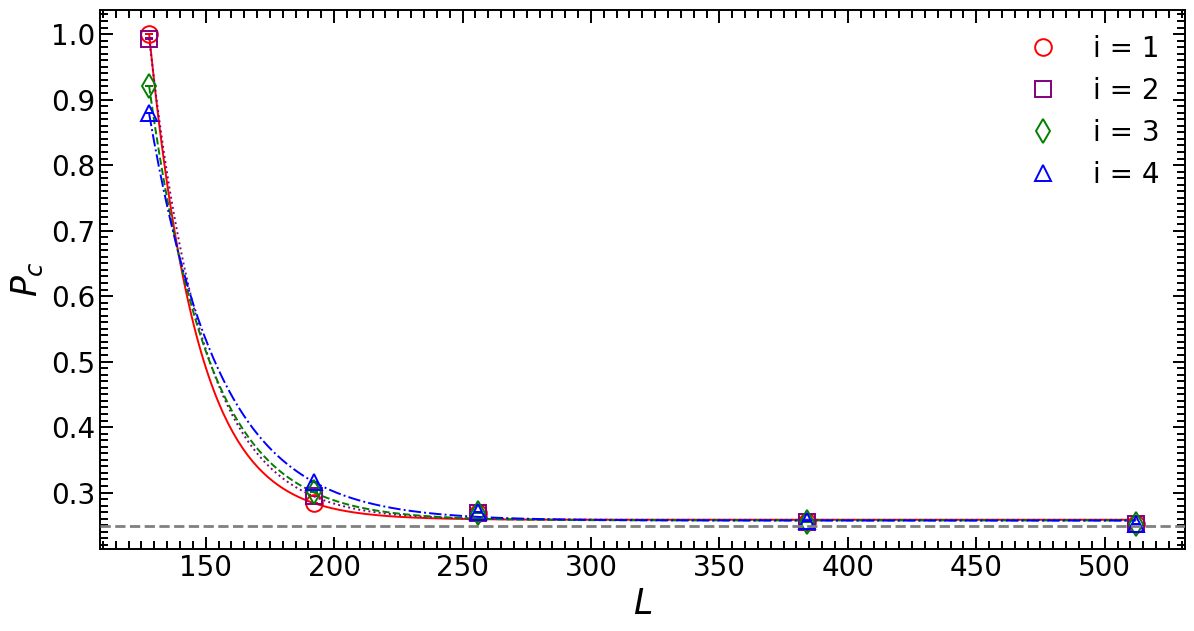

In [46]:
import numpy as np
from scipy.optimize import curve_fit

L_lst = [128, 192, 256, 384, 512]
nc = 4
Nt = 3000
k = 1.0e-06
p0 = 1.0
P0 = 0.1

# smallest value of rho with percolation for L=128
rho_min = df[(df['L']==128) & (df["nc"]==nc) & (df["P0"]==0.1)]['rho'].min()
# biggest value of rho with percolation for L=128 (1/nc)
rho_max = df[(df['L']==128) & (df["nc"]==nc) & (df["P0"]==0.1)]['rho'].max()

df_all = df[(df['Nt']==Nt) & (df['k']==k) & (df['nc']==nc) & (df['p0']==p0) & (df['P0']==P0) & (df['rho']==rho_max)]

fig, ax = plt.subplots(figsize=(14, 7))
orders = [i for i in range(1,nc+1)]


ms = 12
font_tick_size = 20
font_label_size = 25
font_legend_size = 20
markers = ["o", "s", "d", "^"]
mew = 1.4
thickness = 1.4
colors  = ["red", "purple", "green", "blue"]

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

pc_reff = 0.24881182

fit_lines = []  # <-- vai guardar linhas do "relatório" do ajuste

for idx, ord in enumerate(orders):
    df_sub = df_all[(df_all['L'].isin(L_lst)) & (df_all['order']==ord)].sort_values('L')
    prop = df_sub["p_mean"]
    prop_err = df_sub["p_err"]
    nu = 0.875
    #x_scale = [i**(-1/nu) for i in L_lst]
    x_scale = L_lst
    y_scale = prop
    y_err = prop_err

    def exp_sat(x, a, tau, c):
        return c + a*np.exp(-x/tau)

    x = np.asarray(x_scale, float)
    y = np.asarray(y_scale, float)
    s = np.asarray(y_err,   float)

    # ordena por x e evita sigma=0
    i = np.argsort(x)
    x, y, s = x[i], y[i], s[i]
    if np.any(s <= 0):
        s[s <= 0] = np.min(s[s > 0]) if np.any(s > 0) else 1.0

    # chutes iniciais simples (agora com 5 pontos tende a convergir bem)
    c0   = np.mean(y[-2:])          # assíntota ~ últimos pontos
    a0   = y[0] - c0
    tau0 = 0.5*(x.max() - x.min())

    popt, pcov = curve_fit(
        exp_sat, x, y,
        p0=[a0, tau0, c0],
        sigma=s, absolute_sigma=True,
        bounds=([-np.inf, 1e-12, -np.inf], [np.inf, np.inf, np.inf]),
        method="trf",
        maxfev=200000
    )

    a, tau, c = popt
    a_err, tau_err, c_err = np.sqrt(np.diag(pcov))
    # predição nos pontos medidos
    y_hat = exp_sat(x, *popt)

    # R^2 "clássico" (não ponderado)
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    # R^2 ponderado (coerente com sigma)
    w = 1.0 / (s**2)
    y_wmean = np.sum(w * y) / np.sum(w)
    ss_res_w = np.sum(w * (y - y_hat)**2)
    ss_tot_w = np.sum(w * (y - y_wmean)**2)
    r2_w = 1 - ss_res_w/ss_tot_w if ss_tot_w > 0 else np.nan

    # (opcional) qui-quadrado reduzido, bem informativo quando há sigma
    dof = len(y) - len(popt)
    chi2_red = (ss_res_w / dof) if dof > 0 else np.nan
    
    x_fit = np.linspace(x.min(), x.max(), 400)
    y_fit = exp_sat(x_fit, a, tau, c)
    
    ax.errorbar(x_scale, y_scale, yerr=y_err,
                fmt=markers[idx], linestyle='None',  # <- sem traço
                markersize=ms, markerfacecolor='none',
                markeredgewidth=mew, markeredgecolor=colors[idx],
                ecolor=colors[idx], capsize=3)

    ax.plot(x_fit, y_fit, linewidth=thickness, color=colors[idx], ls=ls[idx])

    print(f"R2 = {r2:.6f}, c = {c:.5g} ± {c_err:.2g}")
    #print(c, c_err)

for spine in ax.spines.values():
    spine.set_linewidth(thickness)

ax.set_xlabel(r"$L$", fontsize=font_label_size)
ax.set_ylabel(r"$P_c$", fontsize=font_label_size)
ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness, 
               direction='in', top=True, bottom=True, left=True, right=True)

ax.tick_params(axis='both', which='minor', labelsize=font_tick_size, length=6, width=thickness, 
               direction='in', top=True, bottom=True, left=True, right=True)
#ax.set_yscale('log')
#ax.set_xscale('log')
# Ticks minor
n=10
ax.tick_params(axis='x',   which='minor', length=6, width=thickness)
ax.tick_params(axis='y',   which='minor', length=6, width=thickness)
ax.xaxis.set_minor_locator(AutoMinorLocator(n))
ax.yaxis.set_minor_locator(AutoMinorLocator(n))

ax.axhline(y=pc_reff, color='gray', linestyle='--', lw=2.0, zorder=100)
# --- legenda só com símbolos ---
legend_handles = [
    Line2D([0], [0],
           marker=markers[idx],
           linestyle='None',            # <- remove o traço na legenda
           color=colors[idx],
           markerfacecolor='none',
           markeredgewidth=mew,
           markersize=ms,
           label=f'i = {ord}')
    for idx, ord in enumerate(orders)
]

ax.legend(handles=legend_handles, fontsize=font_legend_size, frameon=False)

plt.show()

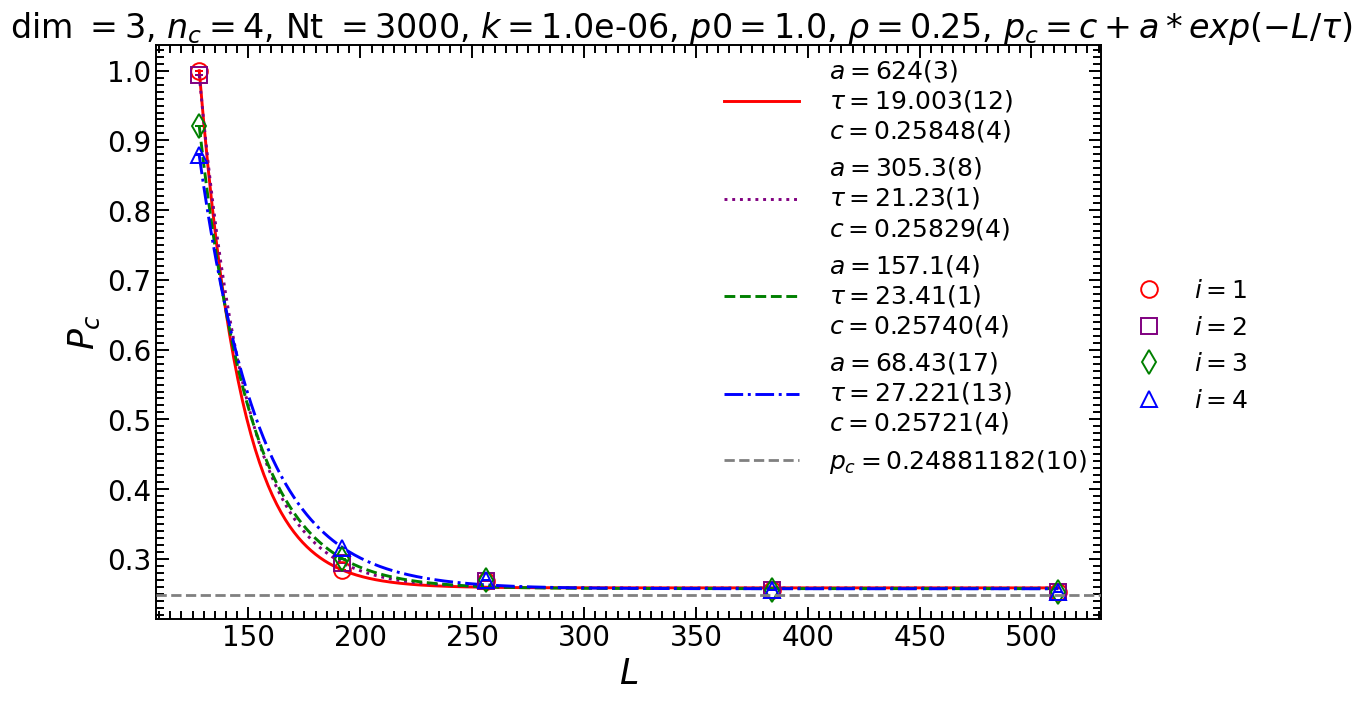

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
from decimal import Decimal, ROUND_HALF_UP, getcontext
from matplotlib.legend_handler import HandlerLine2D

import math

from matplotlib.legend_handler import HandlerLine2D

class HandlerLine2DCentered(HandlerLine2D):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        artists = super().create_artists(
            legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans
        )
        ymid = ydescent + 0.5 * height
        for a in artists:
            if isinstance(a, Line2D):
                xd = np.asarray(a.get_xdata(), dtype=float)
                a.set_ydata(np.full_like(xd, ymid, dtype=float))
        return artists

getcontext().prec = 50

def format_paren(val, err):
    """
    Retorna string no formato valor(erro), com erro arredondado e valor
    com o mesmo número de casas decimais.

    Regra: usa 2 algarismos significativos no erro se o primeiro dígito for 1,
    caso contrário usa 1 algarismo significativo (estilo PDG).
    Ex.: 624.327 ± 2.5 -> 624(3)
          19.0031 ± 0.012 -> 19.003(12)
          21.23 ± 0.0097 -> 21.23(1)
    """
    if err is None or err == 0 or (not np.isfinite(val)) or (not np.isfinite(err)):
        return f"{val:g}"

    err_abs = float(abs(err))
    if err_abs <= 0:
        return f"{val:g}"

    exp = int(math.floor(math.log10(err_abs)))
    m = err_abs / (10**exp)
    first = int(m)

    n_sig = 2 if first == 1 else 1  # PDG-like
    step_exp = exp - (n_sig - 1)

    err_q = Decimal(str(err_abs)).quantize(Decimal(f"1e{step_exp}"), rounding=ROUND_HALF_UP)

    # Remove zeros finais (ex.: 0.010 -> 0.01), para evitar 21.230(10) e virar 21.23(1)
    t = err_q.as_tuple()
    digits = list(t.digits)
    exp2 = t.exponent
    while digits and digits[-1] == 0:
        digits.pop()
        exp2 += 1
    if not digits:
        return f"{val:g}"

    err_int = int("".join(map(str, digits)))
    step_dec = Decimal(f"1e{exp2}")

    val_q = Decimal(str(val)).quantize(step_dec, rounding=ROUND_HALF_UP)

    decimals = max(0, -exp2)
    val_str = f"{val_q:.{decimals}f}" if decimals > 0 else f"{val_q:.0f}"

    return f"{val_str}({err_int})"


L_lst = [128, 192, 256, 384, 512]
nc = 4
Nt = 3000
k = 1.0e-06
p0 = 1.0
P0 = 0.1
dim = 3

rho_min = df[(df['L']==128) & (df["nc"]==nc) & (df["P0"]==0.1)]['rho'].min()
rho_max = df[(df['L']==128) & (df["nc"]==nc) & (df["P0"]==0.1)]['rho'].max()

df_all = df[(df['Nt']==Nt) & (df['k']==k) & (df['nc']==nc) & (df['p0']==p0) & (df['P0']==P0) & (df['rho']==rho_max)]

fig, ax = plt.subplots(figsize=(14, 7))
orders = [i for i in range(1, nc+1)]

ms = 12
font_tick_size = 20
font_label_size = 25
font_legend_size = 18

markers = ["o", "s", "d", "^"]
colors  = ["red", "purple", "green", "blue"]

mew = 1.4
thickness = 1.4

ls = ['solid', 'dotted', 'dashed', 'dashdot',
      (0, (3, 5, 1, 5)), (0, (3, 10, 1, 10)),
      (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

pc_reff = 0.24881182

def exp_sat(x, a, tau, c):
    return c + a*np.exp(-x/tau)

legend_handles_markers = []  # legenda externa (marcadores) -> direita
fit_handles_lines = []       # legenda interna (linhas do ajuste)
fit_labels_lines = []        # legenda interna (texto a,tau,c)

for idx, ord in enumerate(orders):
    df_sub = df_all[(df_all['L'].isin(L_lst)) & (df_all['order']==ord)].sort_values('L')

    prop     = df_sub["p_mean"].to_numpy()
    prop_err = df_sub["p_err"].to_numpy()

    x_scale = np.array(L_lst, dtype=float)
    y_scale = np.array(prop, dtype=float)
    y_err   = np.array(prop_err, dtype=float)

    x = np.asarray(x_scale, float)
    y = np.asarray(y_scale, float)
    s = np.asarray(y_err, float)

    isort = np.argsort(x)
    x, y, s = x[isort], y[isort], s[isort]
    if np.any(s <= 0):
        s[s <= 0] = np.min(s[s > 0]) if np.any(s > 0) else 1.0

    c0   = np.mean(y[-2:])
    a0   = y[0] - c0
    tau0 = 0.5*(x.max() - x.min())

    popt, pcov = curve_fit(
        exp_sat, x, y,
        p0=[a0, tau0, c0],
        sigma=s, absolute_sigma=True,
        bounds=([-np.inf, 1e-12, -np.inf], [np.inf, np.inf, np.inf]),
        method="trf",
        maxfev=200000
    )

    a, tau, c = popt
    a_err, tau_err, c_err = np.sqrt(np.diag(pcov))

    x_fit = np.linspace(x.min(), x.max(), 400)
    y_fit = exp_sat(x_fit, a, tau, c)

    # dados (marcadores)
    ax.errorbar(
        x_scale, y_scale, yerr=y_err,
        fmt=markers[idx], linestyle='None',
        markersize=ms, markerfacecolor='none',
        markeredgewidth=mew, markeredgecolor=colors[idx],
        ecolor=colors[idx], capsize=3
    )

    # ajuste (linha)
    ax.plot(x_fit, y_fit, linewidth=1.5*thickness, color=colors[idx], ls=ls[idx])

    # legenda externa (direita): marcadores + i=ord
    legend_handles_markers.append(
        Line2D([0], [0],
               marker=markers[idx], linestyle='None',
               color=colors[idx],
               markerfacecolor='none',
               markeredgewidth=mew,
               markersize=ms,
               label=rf"$i={ord}$")
    )

    # legenda interna: linha do ajuste + parâmetros no formato valor(erro)
    fit_handles_lines.append(
        Line2D([0], [0],
               linestyle=ls[idx],
               color=colors[idx],
               linewidth=1.5*thickness)
    )

    a_fmt   = format_paren(a,   a_err)
    tau_fmt = format_paren(tau, tau_err)
    c_fmt   = format_paren(c,   c_err)

    fit_labels_lines.append(
        rf"$a={a_fmt}$" "\n"
        rf"$\tau={tau_fmt}$" "\n"
        rf"$c={c_fmt}$"
    )

# box/spines
for spine in ax.spines.values():
    spine.set_linewidth(thickness)

ax.set_xlabel(r"$L$", fontsize=font_label_size)
ax.set_ylabel(r"$P_c$", fontsize=font_label_size)

ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness,
               direction='in', top=True, bottom=True, left=True, right=True)
ax.tick_params(axis='both', which='minor', labelsize=font_tick_size, length=6, width=thickness,
               direction='in', top=True, bottom=True, left=True, right=True)

n = 10
ax.xaxis.set_minor_locator(AutoMinorLocator(n))
ax.yaxis.set_minor_locator(AutoMinorLocator(n))

h_pc = ax.axhline(y=pc_reff, color='gray', linestyle='--', lw=2.0, zorder=100, label='$p_c = 0.24881182(10)$')
fit_handles_lines.append(h_pc)
fit_labels_lines.append(r"$p_c = 0.24881182(10)$")

# Reserve espaço real dentro da FIGURA para a legenda externa (à direita)
fig.subplots_adjust(right=0.80)   # eixo termina em 0.80; sobra faixa 0.20 p/ legenda

# -------- legenda interna: (linhas do ajuste + parâmetros) no canto superior direito --------
leg_inside = ax.legend(
    handles=fit_handles_lines,
    labels=fit_labels_lines,
    loc="upper right",
    bbox_to_anchor=(0.995, 0.995),
    frameon=False,
    borderaxespad=0.0,
    handlelength=3.0,
    handletextpad=1.2,
    labelspacing=0.45,
    fontsize=18,
    handler_map={Line2D: HandlerLine2DCentered()}
)

# -------- legenda externa: (marcadores + i=ord) na faixa à direita da figura --------
fig_leg = fig.legend(
    handles=legend_handles_markers,
    loc="center left",
    bbox_to_anchor=(0.80, 0.5),   # dentro da faixa que sobrou (>=0.80)
    frameon=False,
    fontsize=font_legend_size
)


supt = fig.suptitle(rf"dim $= {dim}$, $n_c = {nc}$, Nt $= {Nt}$, $k = ${k:.1e}, $p0 = {p0}$, $\rho = {0.25}$, $p_c = c + a*exp(-L/\tau)$", fontsize=24, y=0.98)

fig.subplots_adjust(top=0.93)

fig.savefig(
    path_sizes + "/pc_versus_L.png",
    dpi=300,
    bbox_inches="tight",
    bbox_extra_artists=(leg_inside, fig_leg, supt),  # <- inclui o título aqui
    pad_inches=0.05
)

# REGRESSÃO pc = C + a*exp(-L/tau)